<a href="https://colab.research.google.com/github/yusufAbdullahi1/Drought-Prediction-in-Northern-Nigeria/blob/main/Yusuf_Abdullahi_Drought_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTS
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from pathlib import Path
Path("figures").mkdir(exist_ok=True)
print("Imports loaded.")

Imports loaded.


In [17]:
# CELL 2 (REAL GEE DATA VERSION)
#### LOAD REAL EARTH ENGINE DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the real GEE data
df = pd.read_csv("nigeria_drought_monthly.csv")

# Parse date and sort
df["date"] = pd.to_datetime(df["date"], format="%Y-%m")
df = df.sort_values("date").reset_index(drop=True)

print(f"Loaded {len(df)} months from {df['date'].min()} to {df['date'].max()}")
print(f"NDVI range: {df['ndvi'].min():.3f} to {df['ndvi'].max():.3f}")
print(f"Rainfall range: {df['rainfall'].min():.1f} to {df['rainfall'].max():.1f} mm")
df.head()

Loaded 120 months from 2014-01-01 00:00:00 to 2023-12-01 00:00:00
NDVI range: 0.205 to 0.542
Rainfall range: 0.0 to 289.0 mm


,date,year,month,ndvi,rainfall
0,2014-01-01,2014,1,0.247309,0.232195
1,2014-02-01,2014,2,0.226250,0.106863
2,2014-03-01,2014,3,0.222553,5.199831
3,2014-04-01,2014,4,0.238546,33.814985
4,2014-05-01,2014,5,0.288975,80.000218


In [4]:
#### CLEAN AND INSPECT

# I force numeric types, then fill NDVI gaps by interpolation and missing rain with 0.
for col in ["ndvi", "rainfall"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ndvi"] = df["ndvi"].interpolate(method="linear", limit_direction="both")
df["rainfall"] = df["rainfall"].fillna(0)

print("Missing values after cleaning:")
print(df.isna().sum())
df.describe()

Missing values after cleaning:
date        0
year        0
month       0
ndvi        0
rainfall    0
dtype: int64


,date,year,month,ndvi,rainfall
count,120,120.000000,120.000000,120.000000,120.000000
mean,2018-12-16 04:00:00,2018.500000,6.500000,0.335986,70.491399
min,2014-01-01 00:00:00,2014.000000,1.000000,0.204606,0.001580
25%,2016-06-23 12:00:00,2016.000000,3.750000,0.235488,0.304431
50%,2018-12-16 12:00:00,2018.500000,6.500000,0.302512,22.926411
75%,2021-06-08 12:00:00,2021.000000,9.250000,0.433857,127.803887
max,2023-12-01 00:00:00,2023.000000,12.000000,0.542135,289.035548
std,NaN,2.884324,3.466527,0.108093,86.941383


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
#### COMPUTE VCI AND DROUGHT LABELS

# VCI rescales each month's NDVI against the historical range for that SAME calendar month.
# VCI = 100 * (NDVI - NDVI_min) / (NDVI_max - NDVI_min)
# I group by month so, say, every June is compared only against other Junes.

df["ndvi_min"] = df.groupby("month")["ndvi"].transform("min")
df["ndvi_max"] = df.groupby("month")["ndvi"].transform("max")
df["vci"] = 100 * (df["ndvi"] - df["ndvi_min"]) / (df["ndvi_max"] - df["ndvi_min"])

# A month counts as drought when its vegetation condition falls below 35 on the VCI scale.
df["drought_label"] = (df["vci"] < 35).astype(int)

print(f"Drought months: {df['drought_label'].sum():d} of {len(df):d} ({100 * df['drought_label'].mean():.1f}%)")

# Show the first 12 rows to verify
df[["date", "ndvi", "vci", "drought_label"]].head(12)

Drought months: 43 of 120 (35.8%)


,date,ndvi,vci,drought_label
0,2014-01-01,0.247309,56.452660,0
1,2014-02-01,0.226250,50.118976,0
2,2014-03-01,0.222553,65.000344,0
3,2014-04-01,0.238546,100.000000,0
4,2014-05-01,0.288975,100.000000,0
5,2014-06-01,0.346752,76.033737,0
6,2014-07-01,0.402697,25.993992,1
7,2014-08-01,0.501538,35.835340,0
8,2014-09-01,0.500686,17.478230,1
9,2014-10-01,0.448432,48.952781,0


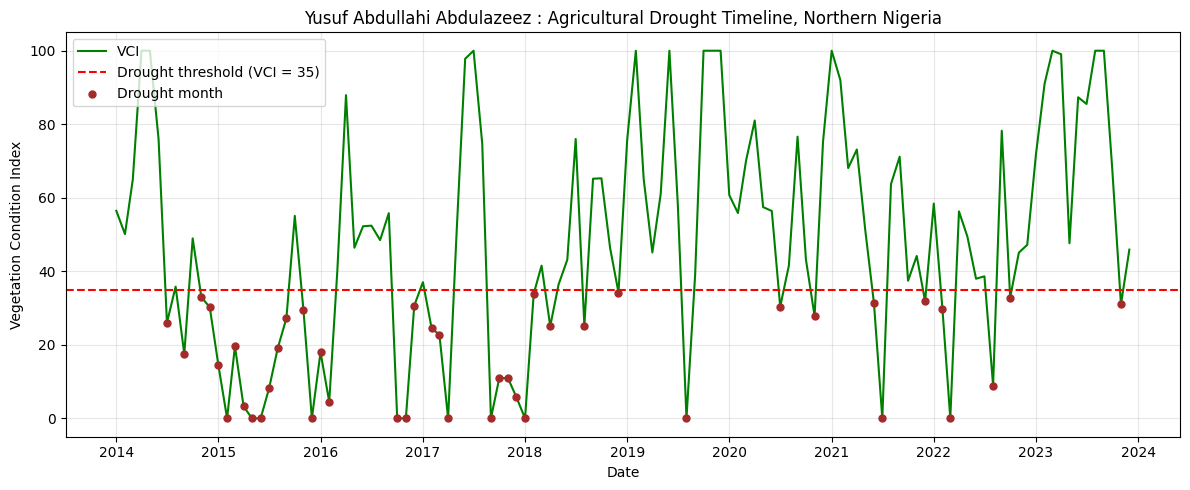

Plot saved as 'figures/drought_timeline.png'


In [7]:
#### DROUGHT TIMELINE VISUALIZATION

# I plot VCI across the ten years, draw the drought threshold, and mark drought months.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["date"], df["vci"], color="green", linewidth=1.5, label="VCI")
ax.axhline(35, color="red", linestyle="--", label="Drought threshold (VCI = 35)")

drought_months = df[df["drought_label"] == 1]
ax.scatter(drought_months["date"], drought_months["vci"],
           color="brown", s=25, zorder=5, label="Drought month")

ax.set_xlabel("Date")
ax.set_ylabel("Vegetation Condition Index")
ax.set_title("Yusuf Abdullahi Abdulazeez : Agricultural Drought Timeline, Northern Nigeria")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/drought_timeline.png", dpi=150)
plt.show()
print("Plot saved as 'figures/drought_timeline.png'")

In [8]:
#### FEATURE ENGINEERING

# The model only sees rainfall and season. I deliberately left NDVI and VCI OUT,
# because the drought label was built from NDVI: using them would leak the answer.

# I encode the month as a smooth cycle so December and January sit next to each other.
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Rainfall memory: this month plus the previous three, and a 3‑month average.
df["rain_lag1"] = df["rainfall"].shift(1)
df["rain_lag2"] = df["rainfall"].shift(2)
df["rain_lag3"] = df["rainfall"].shift(3)
df["rain_roll3"] = df["rainfall"].rolling(3).mean()

# Lagging leaves NaNs in the first three rows, so I drop them (I never fill lags with 0).
df = df.dropna().reset_index(drop=True)

feature_columns = [
    "rainfall", "rain_lag1", "rain_lag2", "rain_lag3",
    "rain_roll3", "month_sin", "month_cos"
]

# Safety guard: make sure no vegetation column slipped into the features.
assert not any(c in feature_columns for c in ["ndvi", "vci"]), "LEAK: NDVI/VCI in features!"

print("Features used:", feature_columns)
print("Drought label counts after dropping NaN rows:")
print(df["drought_label"].value_counts())

Features used: ['rainfall', 'rain_lag1', 'rain_lag2', 'rain_lag3', 'rain_roll3', 'month_sin', 'month_cos']
Drought label counts after dropping NaN rows:
drought_label
0    74
1    43
Name: count, dtype: int64


In [9]:
#### TRAIN / TEST SPLIT

# I split by time, not randomly: the model trains on the earlier years and is tested
# on the most recent ones. Shuffling would let it peek at the future, which is cheating.
X = df[feature_columns]
y = df["drought_label"]

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training months: {len(X_train)}")
print(f"Testing months: {len(X_test)}")
print(f"Drought months in the training set: {int(y_train.sum())}")
print(f"Drought months in the test set: {int(y_test.sum())} of {len(y_test)}")

if y_test.sum() == 0:
    print("⚠️ Note: Test set has zero drought months – this is expected with a rare class.")
    print("The cross‑validated F1 in Cell 9 will be the primary metric.")

Training months: 93
Testing months: 24
Drought months in the training set: 38
Drought months in the test set: 5 of 24


In [10]:
#### TRAIN RANDOM FOREST

# Random Forest is robust, interpretable, and good on small tabular data.
# class_weight='balanced' stops it from ignoring the rarer drought class.
model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Model trained. Predictions made on the test set.")

Model trained. Predictions made on the test set.


In [11]:
#### EVALUATION

# I judge the model on F1, precision and recall for the drought class, never plain accuracy.
print("Classification report (test set):")
print(classification_report(y_test, predictions, zero_division=0))

print("Confusion matrix (test set):")
print(confusion_matrix(y_test, predictions))

# Because droughts are rare, I also run a time‑aware cross‑validation over the WHOLE record.
# I use a manual loop here because cross_val_predict throws an error with TimeSeriesSplit
# (it expects every sample to appear in a test set, which TimeSeriesSplit doesn't guarantee).
tscv = TimeSeriesSplit(n_splits=5)
f1_scores = []

for train_idx, test_idx in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Train a new model for this fold
    model_cv = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    model_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = model_cv.predict(X_test_cv)

    f1_scores.append(f1_score(y_test_cv, y_pred_cv, zero_division=0))

print(f"\nTimeSeriesSplit cross‑validated F1 (mean of {len(f1_scores)} folds): {np.mean(f1_scores):.3f}")
print(f"Individual fold F1 scores: {[round(f, 3) for f in f1_scores]}")

Classification report (test set):
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        19
           1       0.17      0.20      0.18         5

    accuracy                           0.62        24
   macro avg       0.47      0.47      0.47        24
weighted avg       0.65      0.62      0.64        24

Confusion matrix (test set):
[[14  5]
 [ 4  1]]

TimeSeriesSplit cross‑validated F1 (mean of 5 folds): 0.356
Individual fold F1 scores: [0.545, 0.636, 0.0, 0.375, 0.222]


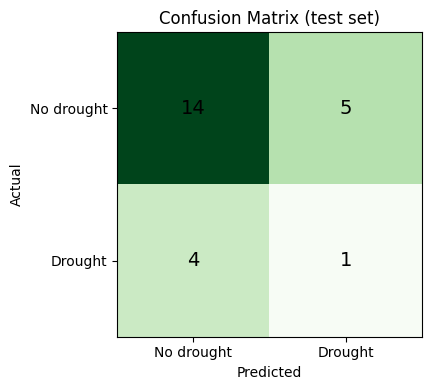

Plot saved as 'figures/confusion_matrix.png'


In [12]:
#### CONFUSION MATRIX VISUALIZATION

# I create a heatmap of the confusion matrix to make it easy to read in the report.
confusion = confusion_matrix(y_test, predictions)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(confusion, cmap="Greens")

# Add numbers inside each cell
for (row, col), value in np.ndenumerate(confusion):
    ax.text(col, row, str(value), ha="center", va="center", fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No drought", "Drought"])
ax.set_yticklabels(["No drought", "Drought"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (test set)")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=150)
plt.show()
print("Plot saved as 'figures/confusion_matrix.png'")


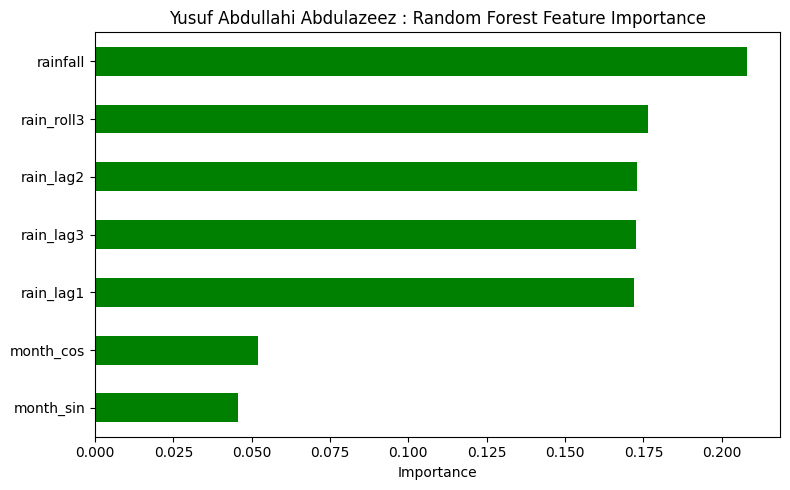

Plot saved as 'figures/feature_importance.png'

Feature importance (highest first):
rainfall      0.208188
rain_roll3    0.176370
rain_lag2     0.173078
rain_lag3     0.172616
rain_lag1     0.172155
month_cos     0.051870
month_sin     0.045723
dtype: float64


In [13]:
#### FEATURE IMPORTANCE

# This shows which rainfall or seasonal signals the model leaned on most.
importance = pd.Series(model.feature_importances_, index=feature_columns)
importance = importance.sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
importance.plot.barh(ax=ax, color="green")
ax.set_xlabel("Importance")
ax.set_title("Yusuf Abdullahi Abdulazeez : Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150)
plt.show()
print("Plot saved as 'figures/feature_importance.png'")

# Print sorted importance for quick reference.
print("\nFeature importance (highest first):")
print(importance.sort_values(ascending=False))

   lag_months  correlation
0           0        0.072
1           1        0.080
2           2        0.011
3           3       -0.081
4           4       -0.080
5           5       -0.003
6           6        0.039

 Strongest response at lag = 1 month(s), r = 0.08


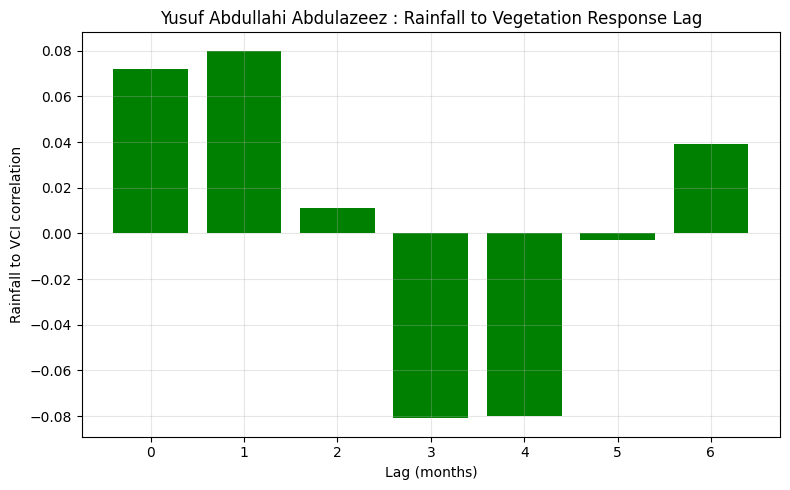

Plot saved as 'figures/rainfall_lag.png'


In [14]:
#### TEMPORAL LAG ANALYSIS

# I correlate rainfall this month with VCI a few months later.
# The lag with the strongest correlation is how long vegetation takes to respond to rain.
lag_records = []
for lag in range(0, 7):
    corr = df["rainfall"].corr(df["vci"].shift(-lag))
    lag_records.append({"lag_months": lag, "correlation": round(corr, 3)})

lag_table = pd.DataFrame(lag_records)
print(lag_table)
best = lag_table.loc[lag_table["correlation"].idxmax()]
print(f"\n Strongest response at lag = {int(best.lag_months)} month(s), r = {best.correlation}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(lag_table["lag_months"], lag_table["correlation"], color="green")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Rainfall to VCI correlation")
ax.set_title("Yusuf Abdullahi Abdulazeez : Rainfall to Vegetation Response Lag")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/rainfall_lag.png", dpi=150)
plt.show()
print("Plot saved as 'figures/rainfall_lag.png'")

In [15]:
#### SAVE RESULTS

# I save a compact results table so the numbers are easy to quote in the report.
precision = precision_score(y_test, predictions, zero_division=0)
recall = recall_score(y_test, predictions, zero_division=0)
f1 = f1_score(y_test, predictions, zero_division=0)
cv_f1 = np.mean(f1_scores)

results = {
    "precision": round(precision, 3),
    "recall": round(recall, 3),
    "f1": round(f1, 3),
    "cv_f1_whole_record": round(cv_f1, 3),
}
print("Final results:")
print(results)

pd.DataFrame([results]).to_csv("model_results.csv", index=False)
lag_table.to_csv("lag_analysis.csv", index=False)
print("\nSaved model_results.csv and lag_analysis.csv")
print("Notebook complete. All figures are in the 'figures/' folder.")
print("\nSummary:")
print(f"   Test set F1 (drought class): {round(f1, 3)}")
print(f"   Cross-validated F1: {round(cv_f1, 3)}")
print(f"   Best rainfall-vegetation lag: {int(best.lag_months)} month(s), r = {best.correlation}")

Final results:
{'precision': 0.167, 'recall': 0.2, 'f1': 0.182, 'cv_f1_whole_record': np.float64(0.356)}

Saved model_results.csv and lag_analysis.csv
Notebook complete. All figures are in the 'figures/' folder.

Summary:
   Test set F1 (drought class): 0.182
   Cross-validated F1: 0.356
   Best rainfall-vegetation lag: 1 month(s), r = 0.08


In [16]:
# Quick calculation for the original 120-month record
original_df = pd.read_csv("nigeria_drought_monthly.csv")

# Recalculate VCI quickly just to get the drought count
original_df["ndvi_min"] = original_df.groupby("month")["ndvi"].transform("min")
original_df["ndvi_max"] = original_df.groupby("month")["ndvi"].transform("max")
original_df["vci"] = 100 * (original_df["ndvi"] - original_df["ndvi_min"]) / (original_df["ndvi_max"] - original_df["ndvi_min"])

drought_count = (original_df["vci"] < 35).sum()
total_months = len(original_df)

print(f"Total months: {total_months}")
print(f"Drought months (VCI < 35): {drought_count}")
print(f"Percentage: {100 * drought_count / total_months:.1f}%")

Total months: 120
Drought months (VCI < 35): 43
Percentage: 35.8%
